In [1]:
# وارد کردن کتابخانه
import pandas as pd
# خواندن فایل فروش
sales = pd.read_csv(r"../data/sales.csv")

In [2]:
# بررسی تعداد مقادیر خالی در هر ستون
print(sales.isnull().sum())

transaction_id    1
customer_id       0
age               0
gender            0
city              0
product           0
category          0
quantity          0
unit_price        0
discount          0
payment_method    0
created_at        0
dtype: int64


In [3]:
# بررسی تعداد ردیف‌های تکراری
print(sales.duplicated().sum())
# حذف ردیف‌های تکراری
sales = sales.drop_duplicates()

0


In [4]:
# تبدیل ستون‌ها به نوع داده مناسب
sales["transaction_id"] = pd.to_numeric(sales["transaction_id"], errors="coerce")
sales["customer_id"] = pd.to_numeric(sales["customer_id"], errors="coerce")
sales["age"] = pd.to_numeric(sales["age"], errors="coerce")
sales["gender"] = sales["gender"].map({"Male": True, "Female": False})
sales["city"] = sales["city"].astype("string")
sales["product"] = sales["product"].astype("string")
sales["category"] = sales["category"].astype("string")
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")
sales["unit_price"] = pd.to_numeric(sales["unit_price"], errors="coerce")
sales["discount"] = pd.to_numeric(sales["discount"], errors="coerce")
sales["payment_method"] = sales["payment_method"].astype("string")
sales["created_at"] = pd.to_datetime(sales["created_at"], format="%y/%m/%d %H:%M", errors="coerce")

In [5]:
# بررسی تعداد مقادیر خالی در هر ستون بعد از تبدیل داده ها
print(sales.isnull().sum())

transaction_id    1
customer_id       0
age               0
gender            0
city              0
product           0
category          0
quantity          1
unit_price        0
discount          0
payment_method    0
created_at        0
dtype: int64


In [6]:

# بررسی تعداد ردیف‌های تکراری بعد از حذف
print(sales.duplicated().sum())
# حذف ردیف‌های تکراری بعد از حذف
sales = sales.drop_duplicates()

0


In [7]:
# حذف سن‌های نامعتبر
sales = sales[(sales["age"] > 0) & (sales["age"] <= 100)]

# حذف تعداد و قیمت‌های نامعتبر
sales = sales[(sales["quantity"] > 0) & (sales["unit_price"] > 0)]

# حذف درصد تخفیف نامعتبر
sales = sales[(sales["discount"] >= 0) & (sales["discount"] <= 100)]

# نمایش تعداد تاریخ‌های نامعتبر
print("Invalid dates:", sales["created_at"].isnull().sum())

Invalid dates: 0


In [8]:
# حذف سطرهایی که قسمت خالی دارند
sales = sales.dropna()

In [9]:
# نمایش نوع داده ستون‌ها
print(sales.dtypes)

transaction_id           float64
customer_id                int64
age                        int64
gender                      bool
city                      string
product                   string
category                  string
quantity                 float64
unit_price                 int64
discount                   int64
payment_method            string
created_at        datetime64[us]
dtype: object


In [10]:
# محاسبه مبلغ نهایی
sales["amount"] = (sales["quantity"] * sales["unit_price"] * (1 - sales["discount"] / 100))

In [11]:
# دیدن ستون مورد نیاز برای محاسبات
print(sales[["quantity", "unit_price", "discount", "amount"]].head(15))

    quantity  unit_price  discount  amount
0        2.0         500        10   900.0
1        1.0         800         5   760.0
2        3.0          20         0    60.0
3        2.0          50        10    90.0
4        1.0         300        15   255.0
6        2.0         800         5  1520.0
11       3.0          20         0    60.0


In [12]:
# پیدا کردن شهر با بیشترین فروش
print(sales.groupby("city")["amount"].sum().sort_values(ascending=False))

# پیدا کردن محصول با بیشترین فروش
print(sales.groupby("product")["amount"].sum().sort_values(ascending=False))

# پیدا کردن دسته محصول با بیشترین فروش
print(sales.groupby("category")["amount"].sum().sort_values(ascending=False))

# شمارش تعداد استفاده از هر روش پرداخت
print(sales["payment_method"].value_counts())

# محاسبه میانگین مبلغ تراکنش
print(sales["amount"].mean())

# پیدا کردن مشتری با بیشترین مبلغ خرید
print(sales.groupby("customer_id")["amount"].sum().sort_values(ascending=False))

# پیدا کردن مشتری با بیشترین تعداد تراکنش
print(sales["customer_id"].value_counts())

# پیدا کردن محصول با بیشترین تعداد فروش
print(sales.groupby("product")["quantity"].sum().sort_values(ascending=False))

# محاسبه فروش بر اساس تاریخ
print(sales.groupby(sales["created_at"].dt.date)["amount"].sum())

# پیدا کردن شهر با بیشترین تعداد تراکنش
print(sales["city"].value_counts())

city
Karaj     2280.0
Tehran    1275.0
Qazvin      90.0
Name: amount, dtype: float64
product
Phone       2280.0
Laptop       900.0
Monitor      255.0
Mouse        120.0
Keyboard      90.0
Name: amount, dtype: float64
category
Electronics    3435.0
Accessories     210.0
Name: amount, dtype: float64
payment_method
Card      5
Cash      1
Online    1
Name: count, dtype: Int64
520.7142857142857
customer_id
102    2280.0
101    1020.0
104     255.0
103      90.0
Name: amount, dtype: float64
customer_id
101    3
102    2
103    1
104    1
Name: count, dtype: int64
product
Mouse       6.0
Phone       3.0
Keyboard    2.0
Laptop      2.0
Monitor     1.0
Name: quantity, dtype: float64
created_at
2026-09-01    1660.0
2026-09-02     150.0
2026-09-03     255.0
2026-09-04    1520.0
2026-09-07      60.0
Name: amount, dtype: float64
city
Tehran    4
Karaj     2
Qazvin    1
Name: count, dtype: Int64


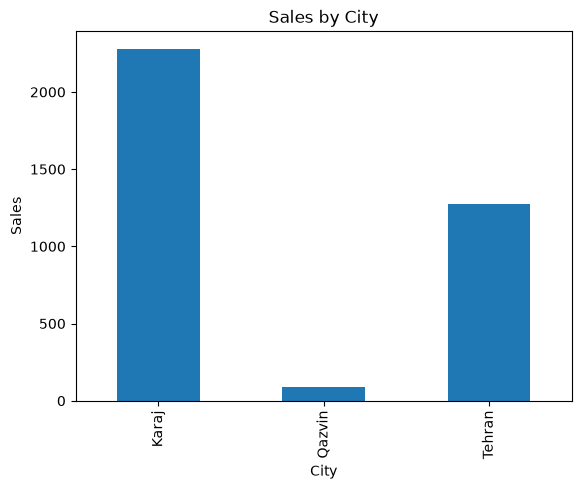

In [13]:
# وارد کردن کتابخانه رسم نمودار
import matplotlib.pyplot as pt
# محاسبه فروش هر شهر
city_sales = sales.groupby("city")["amount"].sum()

# رسم نمودار فروش شهرها
city_sales.plot(kind="bar")
pt.title("Sales by City")
pt.xlabel("City")
pt.ylabel("Sales")
pt.show()


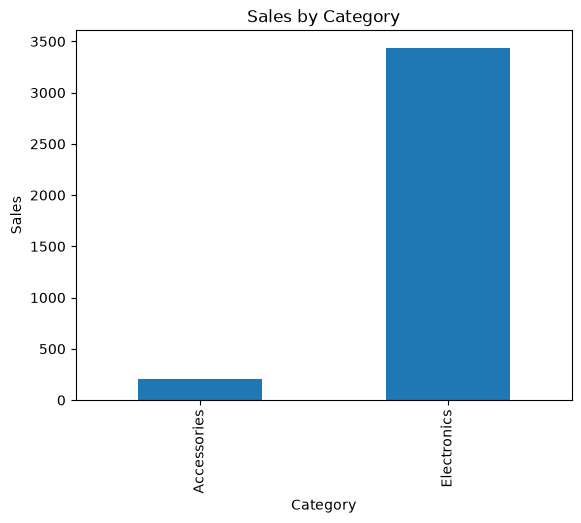

In [14]:
# محاسبه فروش هر دسته محصول
category_sales = sales.groupby("category")["amount"].sum()

# رسم نمودار فروش دسته‌های محصول
category_sales.plot(kind="bar")
pt.title("Sales by Category")
pt.xlabel("Category")
pt.ylabel("Sales")
pt.show()

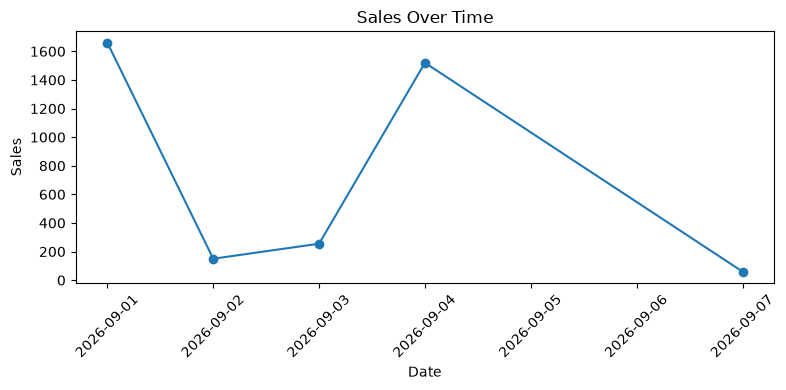

In [15]:
# محاسبه فروش در طول زمان
daily_sales = sales.groupby(
    sales["created_at"].dt.date
)["amount"].sum()

# رسم نمودار فروش در طول زمان
pt.figure(figsize=(8, 4))
daily_sales.plot(kind="line", marker="o")
pt.title("Sales Over Time")
pt.xlabel("Date")
pt.ylabel("Sales")
pt.xticks(rotation=45)
pt.tight_layout()
pt.show()

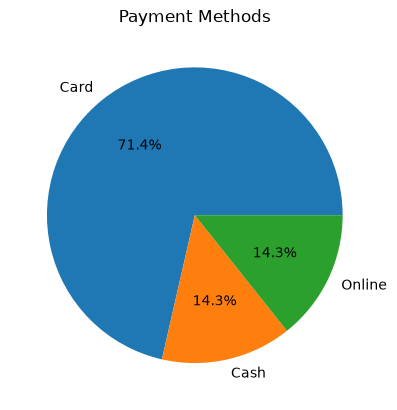

In [16]:
# محاسبه روش های پرداخت
payment = sales["payment_method"].value_counts()

# رسم نمودار روش های پرداخت
payment.plot(kind="pie", autopct="%1.1f%%")
pt.title("Payment Methods")
pt.ylabel("")
pt.show()


In [17]:
# پیدا کردن ۱۰ مشتری با بیشترین مبلغ خرید
top_customers = (
    sales.groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Customers:")
print(top_customers)

# بررسی محصولات خریداری‌شده توسط این مشتریان
customer_products = (
    sales[sales["customer_id"].isin(top_customers.index)]
    .groupby(["customer_id", "product"])["quantity"]
    .sum()
    .reset_index()
    .sort_values(["customer_id", "quantity"], ascending=[True, False])
)

print("\nSold Products:")
print(customer_products)

Top 10 Customers:
customer_id
102    2280.0
101    1020.0
104     255.0
103      90.0
Name: amount, dtype: float64

Sold Products:
   customer_id   product  quantity
1          101     Mouse       6.0
0          101    Laptop       2.0
2          102     Phone       3.0
3          103  Keyboard       2.0
4          104   Monitor       1.0


In [18]:
# بررسی ارتباط تخفیف با تعداد تراکنش مشتریان
customer_behavior = sales.groupby("customer_id").agg(
    avg_discount=("discount", "mean"),
    transaction_count=("transaction_id", "count")
)

print(customer_behavior)

             avg_discount  transaction_count
customer_id                                 
101              3.333333                  3
102              5.000000                  2
103             10.000000                  1
104             15.000000                  1


In [19]:
# ساخت جدول ویژگی‌های رفتاری مشتریان
customer_data = sales.groupby("customer_id").agg(
    total_spent=("amount", "sum"),
    transaction_count=("transaction_id", "count"),
    total_quantity=("quantity", "sum"),
    avg_transaction=("amount", "mean"),
    avg_discount=("discount", "mean")
)

print(customer_data)

             total_spent  transaction_count  total_quantity  avg_transaction  \
customer_id                                                                    
101               1020.0                  3             8.0            340.0   
102               2280.0                  2             3.0           1140.0   
103                 90.0                  1             2.0             90.0   
104                255.0                  1             1.0            255.0   

             avg_discount  
customer_id                
101              3.333333  
102              5.000000  
103             10.000000  
104             15.000000  


In [20]:
# انتخاب ویژگی‌هایی که برای دسته‌بندی مشتریان استفاده می‌شوند
features = customer_data[
    [
        "total_spent",
        "transaction_count",
        "total_quantity",
        "avg_transaction",
        "avg_discount"
    ]
]

In [21]:
# وارد کردن ابزار استانداردسازی داده‌ها
from sklearn.preprocessing import StandardScaler as std

scaler = std()

scaled = scaler.fit_transform(features)

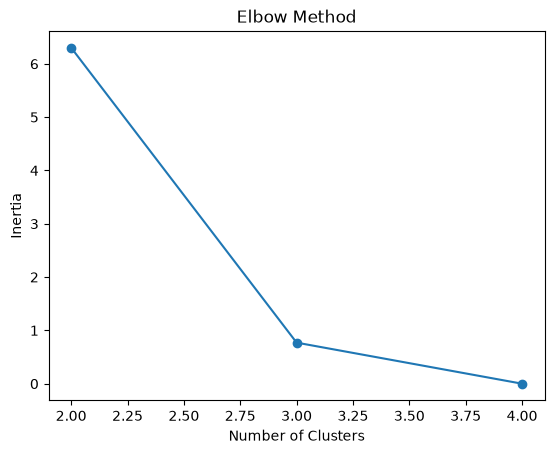

In [22]:
# وارد کردن الگوریتم
from sklearn.cluster import KMeans
# ایجاد یک لیست برای ذخیره مقدار خطای هر تعداد خوشه
inertia = []
# بررسی تعداد خوشه‌ها از ۲ تا ۴
for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # اجرای مدل روی داده‌های استانداردشده
    kmeans.fit(scaled)
    # ذخیره مقدار خطای مدل
    inertia.append(kmeans.inertia_)

pt.plot(range(2, 5), inertia, marker="o")
pt.xlabel("Number of Clusters")
pt.ylabel("Inertia")
pt.title("Elbow Method")
pt.show()

In [23]:
# تعیین تعداد بهینه خوشه‌ها
optimal_k = 2

print("Optimal number of clusters:", optimal_k)

# ساخت مدل نهایی K-Means
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# اجرای مدل
kmeans_final.fit(scaled)

# اختصاص شماره خوشه به هر مشتری
customer_data["cluster"] = kmeans_final.labels_

# نمایش نتیجه
print(customer_data)

Optimal number of clusters: 2
             total_spent  transaction_count  total_quantity  avg_transaction  \
customer_id                                                                    
101               1020.0                  3             8.0            340.0   
102               2280.0                  2             3.0           1140.0   
103                 90.0                  1             2.0             90.0   
104                255.0                  1             1.0            255.0   

             avg_discount  cluster  
customer_id                         
101              3.333333        0  
102              5.000000        0  
103             10.000000        1  
104             15.000000        1  


In [24]:
# بررسی ویژگی‌های هر خوشه
cluster_summary = (
    customer_data
    .groupby("cluster")
    .agg(
        total_spent=("total_spent", "mean"),
        transaction_count=("transaction_count", "mean"),
        total_quantity=("total_quantity", "mean"),
        avg_transaction=("avg_transaction", "mean"),
        avg_discount=("avg_discount", "mean")
    )
)

print(cluster_summary)

         total_spent  transaction_count  total_quantity  avg_transaction  \
cluster                                                                    
0             1650.0                2.5             5.5            740.0   
1              172.5                1.0             1.5            172.5   

         avg_discount  
cluster                
0            4.166667  
1           12.500000  


In [25]:
# مرتب‌سازی مشتری‌ها بر اساس خوشه
clustered_customers = customer_data.sort_values("cluster")

print(clustered_customers)

             total_spent  transaction_count  total_quantity  avg_transaction  \
customer_id                                                                    
101               1020.0                  3             8.0            340.0   
102               2280.0                  2             3.0           1140.0   
103                 90.0                  1             2.0             90.0   
104                255.0                  1             1.0            255.0   

             avg_discount  cluster  
customer_id                         
101              3.333333        0  
102              5.000000        0  
103             10.000000        1  
104             15.000000        1  


In [26]:
# تعداد مشتریان در هر خوشه
cluster_counts = customer_data["cluster"].value_counts().sort_index()

print(cluster_counts)

cluster
0    2
1    2
Name: count, dtype: int64


In [27]:
print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
         total_spent  transaction_count  total_quantity  avg_transaction  \
cluster                                                                    
0             1650.0                2.5             5.5            740.0   
1              172.5                1.0             1.5            172.5   

         avg_discount  
cluster                
0            4.166667  
1           12.500000  


In [28]:
# خلاصه نهایی خوشه‌ها
cluster_summary = (
    customer_data
    .groupby("cluster")
    .agg(
        customers=("cluster", "count"),
        average_spent=("total_spent", "mean"),
        average_transactions=("transaction_count", "mean"),
        average_quantity=("total_quantity", "mean"),
        average_transaction=("avg_transaction", "mean"),
        average_discount=("avg_discount", "mean")
    )
)

print(cluster_summary)

         customers  average_spent  average_transactions  average_quantity  \
cluster                                                                     
0                2         1650.0                   2.5               5.5   
1                2          172.5                   1.0               1.5   

         average_transaction  average_discount  
cluster                                         
0                      740.0          4.166667  
1                      172.5         12.500000  


In [29]:
# نمایش مشتریان هر خوشه
for cluster in sorted(customer_data["cluster"].unique()):
    print(f"\nCluster {cluster}:")
    print(customer_data[customer_data["cluster"] == cluster])


Cluster 0:
             total_spent  transaction_count  total_quantity  avg_transaction  \
customer_id                                                                    
101               1020.0                  3             8.0            340.0   
102               2280.0                  2             3.0           1140.0   

             avg_discount  cluster  
customer_id                         
101              3.333333        0  
102              5.000000        0  

Cluster 1:
             total_spent  transaction_count  total_quantity  avg_transaction  \
customer_id                                                                    
103                 90.0                  1             2.0             90.0   
104                255.0                  1             1.0            255.0   

             avg_discount  cluster  
customer_id                         
103                  10.0        1  
104                  15.0        1  


In [30]:
# ذخیره داده‌های پاکسازی‌شده
sales.to_csv("../data/clean_sales.csv", index=False)


In [31]:
# خواندن فایل‌های بزرگ به صورت بخش‌های 100 هزار ردیفی
for chunk in pd.read_csv("../data/sales.csv", chunksize=100000):
    print(len(chunk))

12
